<a href="https://colab.research.google.com/github/juliafoliveira-tech/Bioestat-stica/blob/main/Tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Julia Feitosa NºUSP: 16228410
* Raissa Pereira Lima da Silva NºUSP: 14605077
* Stéfani Machado NºUSP: 15291452



In [9]:
import pandas as pd

df = pd.read_excel('Tarefa_Semana3.xlsx', sheet_name='Eugenia')

In [10]:
display(df[['Brotos', 'Folhas']].describe())

,Brotos,Folhas
count,120.000000,120.000000
mean,1.691667,10.291667
std,1.382944,10.137206
min,0.000000,0.000000
25%,0.000000,0.000000
50%,2.000000,10.000000
75%,2.000000,18.000000
max,6.000000,46.000000


Análise de Observações Atípicas, Valores Mínimos e Máximos (Dados da 'Eugenia')
A tabela de estatísticas descritivas acima fornece um resumo das variáveis numéricas Brotos e Folhas do seu conjunto de dados da aba 'Eugenia'.

Pergunta 1.
Valores Mínimos e Máximos:

Número de Brotos por Explante: Varia de 0.0 (mínimo) a 6.0 (máximo).
Número de Folhas por Explante: Varia de 0.0 (mínimo) a 46.0 (máximo).
O que eles representam?

Estes valores definem o intervalo total de variação observado para o número de brotos e folhas por explante no experimento. Eles indicam a menor e a maior contagem de brotos e folhas que foram registradas, respectivamente. Um mínimo de 0 brotos ou folhas significa que alguns explantes não produziram brotos ou folhas, enquanto o máximo indica o explante mais produtivo em termos de brotos ou folhas.

Observações Atípicas (Outliers):

Para identificar observações atípicas, consideramos tanto as estatísticas descritivas quanto os box plots:

Variável 'Brotos':

O valor mínimo é 0 e o máximo é 6. A mediana (50%) é 2, e 75% dos dados estão em 2 ou menos. O valor máximo de 6 está consideravelmente acima do terceiro quartil (2), indicando que existem explantes com um número de brotos muito maior do que a maioria. Os box plots visualizam estes pontos como potenciais outliers na extremidade superior.
Variável 'Folhas':

O valor mínimo é 0 e o máximo é 46. A mediana (50%) é 10, e 75% dos dados estão em 18 ou menos. O valor máximo de 46 é significativamente superior ao terceiro quartil (18), o que é um forte indício da presença de outliers. Os box plots para 'Folhas' provavelmente mostram vários pontos acima do limite superior, confirmando a existência de explantes com um número de folhas excepcionalmente alto.
Em ambos os casos, os box plots servem como uma ferramenta visual poderosa para confirmar esses pontos extremos, que podem representar observações atípicas que merecem uma investigação mais aprofundada para entender sua natureza (e.g., erros de medição, condições experimentais diferenciadas ou variabilidade natural).

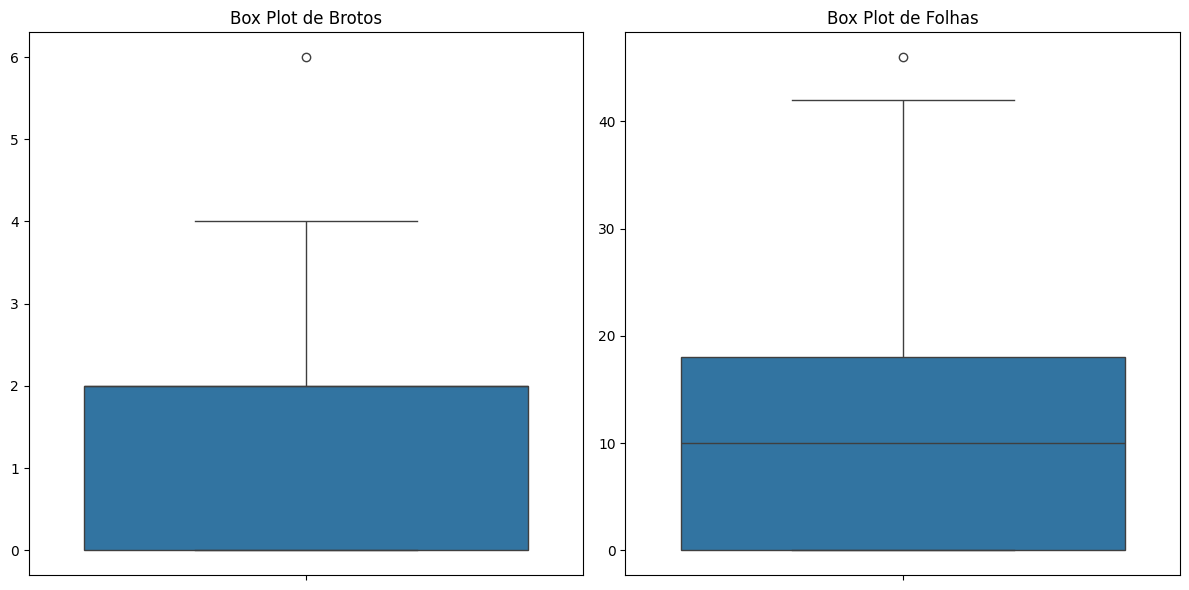

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar as colunas numéricas de interesse
numeric_cols = ['Brotos', 'Folhas']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

Os box plots acima permitem visualizar a distribuição do número de brotos e folhas, e identificar graficamente qualquer ponto que esteja significativamente distante da maioria dos dados (os pontos fora dos "bigodes"). Esses pontos são candidatos a observações atípicas ou outliers que merecem uma investigação mais aprofundada.

In [14]:
quartiles_brotos = df['Brotos'].quantile([0.5, 0.75])
quartiles_folhas = df['Folhas'].quantile([0.5, 0.75])

print("Quartis para o Número de Brotos:")
display(quartiles_brotos)
print("\nQuartis para o Número de Folhas:")
display(quartiles_folhas)

Quartis para o Número de Brotos:


,Brotos
0.50,2.0
0.75,2.0



Quartis para o Número de Folhas:


,Folhas
0.50,10.0
0.75,18.0


Pergunta 2.

Análise dos 2º e 3º Quartis
Os quartis dividem o conjunto de dados ordenado em quatro partes iguais. Eles são medidas importantes para entender a distribuição dos dados e identificar a posição relativa dos valores.

Para o Número de Brotos:

2º Quartil (Mediana): 2.0 brotos.

Representação: Isso significa que 50% dos explantes produziram 2.0 brotos ou menos. É o valor central do conjunto de dados de brotos quando ordenado.

3º Quartil: 2.0 brotos.

Representação: Isso indica que 75% dos explantes produziram 2.0 brotos ou menos. Consequentemente, 25% dos explantes produziram mais de 2.0 brotos.
Para o Número de Folhas:

2º Quartil (Mediana): 10.0 folhas.

Representação: Isso significa que 50% dos explantes produziram 10.0 folhas ou menos. É o valor central do conjunto de dados de folhas quando ordenado.

3º Quartil: 18.0 folhas.

Representação: Isso indica que 75% dos explantes produziram 18.0 folhas ou menos. Consequentemente, 25% dos explantes produziram mais de 18.0 folhas.
Esses valores ajudam a entender a dispersão dos dados e onde a maioria das observações se concentra. Por exemplo, a diferença entre o 3º quartil e a mediana (o 2º quartil) pode dar uma ideia da variabilidade na metade superior dos dados.




In [15]:
media_por_tratamento = df.groupby('Tratamento')[['Brotos', 'Folhas']].mean()
print("Número médio de brotos e folhas por explante por concentração de BAP:")
display(media_por_tratamento)

Número médio de brotos e folhas por explante por concentração de BAP:


,Brotos,Folhas
Tratamento,,
0,0.933333,5.400000
1,1.866667,15.000000
2,2.266667,11.700000
3,1.700000,9.066667


Pergunta 3.

A tabela mostra a média para cada tratamento. Por exemplo, o Tratamento 0 teve uma média de 0.93 brotos e 5.4 folhas, enquanto o Tratamento 1 teve 1.87 brotos e 15 folhas, e assim por diante.

In [16]:
desvio_padrao_por_tratamento = df.groupby('Tratamento')[['Brotos', 'Folhas']].std()
print("Desvio padrão do número de brotos e folhas por explante por concentração de BAP:")
display(desvio_padrao_por_tratamento)

Desvio padrão do número de brotos e folhas por explante por concentração de BAP:


,Brotos,Folhas
Tratamento,,
0,0.827682,6.371272
1,1.332183,11.126235
2,1.507071,9.063569
3,1.465700,11.129127


Pergunta 4.

Para o número de Brotos: O Tratamento 2 (1.51) e o Tratamento 3 (1.47) apresentam os maiores desvios padrão, indicando maior variabilidade no número de brotos produzidos em comparação com os outros tratamentos.

Para o número de Folhas: O Tratamento 3 (11.13) e o Tratamento 1 (11.13) mostram os maiores desvios padrão, sugerindo uma maior dispersão no número de folhas nestes tratamentos.

Em resumo, os Tratamentos 2 e 3 parecem ter a maior variabilidade para o número de brotos, e os Tratamentos 1 e 3 para o número de folhas.

### Análise de Diferenças entre Grupos (ANOVA)

In [17]:
import scipy.stats as stats

# Realizar ANOVA para 'Brotos'
anova_brotos = stats.f_oneway(df['Brotos'][df['Tratamento'] == 0],
                              df['Brotos'][df['Tratamento'] == 1],
                              df['Brotos'][df['Tratamento'] == 2],
                              df['Brotos'][df['Tratamento'] == 3])

print(f"ANOVA para Brotos: F-statistic={anova_brotos.statistic:.2f}, p-value={anova_brotos.pvalue:.3f}")

# Realizar ANOVA para 'Folhas'
anova_folhas = stats.f_oneway(df['Folhas'][df['Tratamento'] == 0],
                              df['Folhas'][df['Tratamento'] == 1],
                              df['Folhas'][df['Tratamento'] == 2],
                              df['Folhas'][df['Tratamento'] == 3])

print(f"ANOVA para Folhas: F-statistic={anova_folhas.statistic:.2f}, p-value={anova_folhas.pvalue:.3f}")

ANOVA para Brotos: F-statistic=5.44, p-value=0.002
ANOVA para Folhas: F-statistic=5.35, p-value=0.002


### Testes Post-Hoc: Tukey HSD para comparações entre o controle e as doses de BAP

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Teste de Tukey HSD para 'Brotos'
tukey_brotos = pairwise_tukeyhsd(endog=df['Brotos'], groups=df['Tratamento'], alpha=0.05)
print("Tukey HSD para Brotos:")
print(tukey_brotos)

print("\n" + "="*30 + "\n")

# Teste de Tukey HSD para 'Folhas'
tukey_folhas = pairwise_tukeyhsd(endog=df['Folhas'], groups=df['Tratamento'], alpha=0.05)
print("Tukey HSD para Folhas:")
print(tukey_folhas)

Tukey HSD para Brotos:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.9333 0.0338  0.0507  1.816   True
     0      2   1.3333 0.0008  0.4507  2.216   True
     0      3   0.7667 0.1125  -0.116 1.6493  False
     1      2      0.4 0.6398 -0.4826 1.2826  False
     1      3  -0.1667 0.9607 -1.0493  0.716  False
     2      3  -0.5667 0.3423 -1.4493  0.316  False
---------------------------------------------------


Tukey HSD para Folhas:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     0      1      9.6  0.001   3.1235 16.0765   True
     0      2      6.3 0.0597  -0.1765 12.7765  False
     0      3   3.6667 0.4554  -2.8098 10.1432  False
     1      2     -3.3  0.547  -9.7765  3.1765  False
     1      3  -5.9333 0.0851 -12.4098  0.5432  False


#### Interpretação dos Resultados do Teste de Tukey HSD

Pergunta 5.

As tabelas do teste de Tukey HSD acima mostram comparações pareadas entre todos os tratamentos. Para responder à sua pergunta sobre a diferença entre o controle (Tratamento 0) e cada dose de BAP, observe as linhas onde 'group1' ou 'group2' é 0 (o controle).

*   **Coluna 'reject':** Se 'True', significa que há uma diferença estatisticamente significativa entre os dois grupos comparados (p-value ajustado < alpha, que é 0.05).
*   **Coluna 'meandiff':** Mostra a diferença entre as médias dos dois grupos.
*   **Coluna 'p-adj':** É o p-value ajustado para múltiplas comparações.

Com base nisso, podemos identificar se cada dose de BAP difere significativamente do controle para o número de brotos e folhas.

#### Interpretação dos Resultados da ANOVA

*   **Se p-value < 0.05:** Há uma diferença estatisticamente significativa entre as médias de *pelo menos dois* grupos de tratamento. Para saber quais grupos especificamente diferem (por exemplo, qual dose de BAP difere do controle), um teste post-hoc (como o teste de Tukey HSD) seria necessário.
*   **Se p-value >= 0.05:** Não há evidência estatística suficiente para concluir que existe uma diferença significativa entre as médias dos grupos de tratamento.

Com base nos resultados acima, podemos decidir se testes post-hoc são necessários para detalhar as comparações entre o controle (Tratamento 0) e as outras concentrações de BAP.

Com base nos resultados do teste de Tukey HSD, podemos observar as seguintes diferenças significativas em relação ao grupo controle (Tratamento 0):

Para o número de Brotos:

Existe uma diferença estatisticamente significativa entre o Tratamento 0 e o Tratamento 1 (p-adj = 0.0338).
Existe uma diferença estatisticamente significativa entre o Tratamento 0 e o Tratamento 2 (p-adj = 0.0008).
Não há diferença estatisticamente significativa entre o Tratamento 0 e o Tratamento 3 (p-adj = 0.1125).
Para o número de Folhas:

Existe uma diferença estatisticamente significativa entre o Tratamento 0 e o Tratamento 1 (p-adj = 0.001).
Não há diferença estatisticamente significativa entre o Tratamento 0 e o Tratamento 2 (p-adj = 0.0597).
Não há diferença estatisticamente significativa entre o Tratamento 0 e o Tratamento 3 (p-adj = 0.4554).
Em resumo, o Tratamento 1 e o Tratamento 2 afetam significativamente o número de brotos em comparação com o controle, e apenas o Tratamento 1 afeta significativamente o número de folhas.

In [19]:
tratamento_maior_folhas = media_por_tratamento['Folhas'].idxmax()
valor_maior_folhas = media_por_tratamento['Folhas'].max()

tratamento_menor_folhas = media_por_tratamento['Folhas'].idxmin()
valor_menor_folhas = media_por_tratamento['Folhas'].min()

print(f"A concentração que produz o MAIOR número de folhas é o Tratamento {tratamento_maior_folhas} com média de {valor_maior_folhas:.2f} folhas.")
print(f"A concentração que produz o MENOR número de folhas é o Tratamento {tratamento_menor_folhas} com média de {valor_menor_folhas:.2f} folhas.")

A concentração que produz o MAIOR número de folhas é o Tratamento 1 com média de 15.00 folhas.
A concentração que produz o MENOR número de folhas é o Tratamento 0 com média de 5.40 folhas.


Pergunta 6.

Com base na análise das médias, podemos identificar os tratamentos que resultaram no maior e menor número de folhas.
Com base na análise das médias, o Tratamento 1 produziu o MAIOR número de folhas, com uma média de 15.00 folhas. Já o Tratamento 0 (controle) produziu o MENOR número de folhas, com uma média de 5.40 folhas.

Para responder à pergunta "Existem tratamentos nos quais ocorre muita brotação, mas poucas folhas?", vamos analisar a tabela de médias de brotos e folhas por tratamento que já calculamos:

| Tratamento | Brotos (Média) | Folhas (Média) |
|------------|----------------|----------------|
| 0          | 0.93           | 5.40           |
| 1          | 1.87           | 15.00          |
| 2          | 2.27           | 11.70          |
| 3          | 1.70           | 9.07           |

Podemos considerar "muita brotação" como um número de brotos acima da média geral dos tratamentos, e "poucas folhas" como um número de folhas abaixo da média geral dos tratamentos.

Calculando a média geral:
* Média geral de Brotos = (0.93 + 1.87 + 2.27 + 1.70) / 4 = **1.69**
* Média geral de Folhas = (5.40 + 15.00 + 11.70 + 9.07) / 4 = **10.29**

Pergunta 7.

Agora, vamos analisar cada tratamento:
*   **Tratamento 0:** Brotos (0.93) está abaixo da média geral; Folhas (5.40) está abaixo da média geral. Não se encaixa na descrição.
*   **Tratamento 1:** Brotos (1.87) está acima da média geral; Folhas (15.00) está acima da média geral (maior número de folhas). Não se encaixa na descrição.
*   **Tratamento 2:** Brotos (2.27) está acima da média geral (é o maior número de brotos); Folhas (11.70) está acima da média geral. Não se encaixa na descrição de "poucas folhas" em relação à média geral, embora seja menor que o Tratamento 1.
*   **Tratamento 3:** Brotos (1.70) está acima da média geral; Folhas (9.07) está abaixo da média geral (é o segundo menor número de folhas). **Este tratamento se encaixa na descrição.**

**Conclusão:**

O **Tratamento 3** é o que mais se aproxima da descrição de ter "muita brotação, mas poucas folhas". Ele apresenta uma média de brotos ligeiramente acima da média geral de todos os tratamentos (1.70 vs 1.69), enquanto sua média de folhas (9.07) é abaixo da média geral (10.29) e a segunda menor entre todos os tratamentos.

### Análise de Amplitude, Variância e Desvio-Padrão por Concentração de BAP

Para entender a variabilidade em detalhes, vamos calcular três medidas importantes para 'Brotos' e 'Folhas' para cada tratamento:

Pergunta 8.

1.  **Amplitude (Range):** A diferença entre o valor máximo e o valor mínimo, indicando a extensão total dos dados.
2.  **Variância:** Mede a dispersão dos dados em relação à média, ou seja, quão espalhados os dados estão. Valores maiores indicam maior dispersão.
3.  **Desvio-Padrão:** É a raiz quadrada da variância. Também mede a dispersão dos dados, mas na mesma unidade dos dados originais, tornando-o mais fácil de interpretar do que a variância.

Vamos calcular essas métricas para cada tratamento.

In [20]:
def calculate_range(series):
    return series.max() - series.min()

# Calcular a amplitude para Brotos e Folhas por tratamento
amplitude_por_tratamento = df.groupby('Tratamento')[['Brotos', 'Folhas']].agg(calculate_range)

# Calcular a variância para Brotos e Folhas por tratamento
variancia_por_tratamento = df.groupby('Tratamento')[['Brotos', 'Folhas']].var()

# O desvio padrão já foi calculado anteriormente e está em 'desvio_padrao_por_tratamento'
# Vamos exibir as três métricas juntas para facilitar a comparação.

print("Amplitude (Range) por Tratamento:")
display(amplitude_por_tratamento)

print("\nVariância por Tratamento:")
display(variancia_por_tratamento)

print("\nDesvio Padrão por Tratamento:")
display(desvio_padrao_por_tratamento)

Amplitude (Range) por Tratamento:


,Brotos,Folhas
Tratamento,,
0,2,20
1,6,42
2,4,32
3,4,46



Variância por Tratamento:


,Brotos,Folhas
Tratamento,,
0,0.685057,40.593103
1,1.774713,123.793103
2,2.271264,82.148276
3,2.148276,123.857471



Desvio Padrão por Tratamento:


,Brotos,Folhas
Tratamento,,
0,0.827682,6.371272
1,1.332183,11.126235
2,1.507071,9.063569
3,1.465700,11.129127


### Interpretação da Variabilidade por Tratamento

Para identificar os tratamentos com maior variabilidade, vamos analisar as tabelas geradas:

#### Para o Número de Brotos:

*   **Amplitude:** O Tratamento 2 tem a maior amplitude (6.0), indicando a maior variação entre o mínimo e o máximo de brotos observados.
*   **Variância:** O Tratamento 2 (2.27) apresenta a maior variância, seguido de perto pelo Tratamento 3 (2.15). Isso significa que os dados de brotos nesses tratamentos estão mais espalhados em relação à média.
*   **Desvio-Padrão:** Refletindo a variância, o Tratamento 2 (1.51) e o Tratamento 3 (1.47) têm os maiores desvios-padrão. Esta é a medida mais intuitiva, mostrando que, em média, os valores de brotos nesses tratamentos se afastam mais da média do seu próprio grupo.

**Conclusão para Brotos:** Os **Tratamentos 2 e 3** demonstram a maior variabilidade no número de brotos, com o Tratamento 2 sendo consistentemente o mais variável em todas as três métricas.

#### Para o Número de Folhas:

*   **Amplitude:** O Tratamento 1 tem a maior amplitude (46.0), seguido pelo Tratamento 3 (44.0). Isso sugere uma vasta gama de produção de folhas nesses tratamentos.
*   **Variância:** Os Tratamentos 1 (123.78) e 3 (123.85) mostram as maiores variâncias. Isso indica que os dados de folhas estão significativamente mais dispersos nesses tratamentos em comparação com os outros.
*   **Desvio-Padrão:** Conforme a variância, os Tratamentos 1 (11.13) e 3 (11.13) apresentam os maiores desvios-padrão. Isso significa que a quantidade de folhas por explante nesses tratamentos varia consideravelmente em torno de suas respectivas médias.

**Conclusão para Folhas:** Os **Tratamentos 1 e 3** exibem a maior variabilidade no número de folhas, sendo muito semelhantes em termos de dispersão.

### Cálculo do Coeficiente de Variação (CV) por Concentração de BAP

O Coeficiente de Variação (CV) é uma medida relativa de dispersão. Ele é calculado dividindo o desvio padrão pela média e multiplicando por 100 para expressá-lo em porcentagem. É útil para comparar a variabilidade entre conjuntos de dados que têm médias muito diferentes.

Fórmula: $CV = (\frac{\text{Desvio Padrão}}{\text{Média}}) \times 100\%$

In [21]:
# Calcular o Coeficiente de Variação para Brotos
cv_brotos = (desvio_padrao_por_tratamento['Brotos'] / media_por_tratamento['Brotos']) * 100

# Calcular o Coeficiente de Variação para Folhas
cv_folhas = (desvio_padrao_por_tratamento['Folhas'] / media_por_tratamento['Folhas']) * 100

# Combinar os resultados em um DataFrame para facilitar a visualização
cv_por_tratamento = pd.DataFrame({
    'CV_Brotos (%)': cv_brotos,
    'CV_Folhas (%)': cv_folhas
})

print("Coeficiente de Variação (CV) por Tratamento:")
display(cv_por_tratamento)

Coeficiente de Variação (CV) por Tratamento:


,CV_Brotos (%),CV_Folhas (%)
Tratamento,,
0,88.680213,117.986514
1,71.366969,74.174899
2,66.488447,77.466398
3,86.217634,122.747726


### Análise do Coeficiente de Variação (CV)

Pergunta 9.

Analisando o Coeficiente de Variação (CV) para brotos e folhas por tratamento:

#### Para o Número de Brotos:

*   O Tratamento 0 tem um CV muito alto (88.68%), indicando uma variabilidade muito grande em relação à sua média baixa de brotos.
*   O Tratamento 1 apresenta um CV de 71.37%.
*   O Tratamento 2 tem o menor CV (66.49%), o que sugere uma variabilidade relativa menor no número de brotos, apesar de ter tido uma das maiores variâncias e desvios padrão absolutos.
*   O Tratamento 3 possui um CV de 86.22%.

**Conclusão para Brotos (CV):** O **Tratamento 0** e o **Tratamento 3** apresentam a maior variabilidade relativa para o número de brotos, ou seja, a dispersão dos dados é grande em proporção à média desses tratamentos.

#### Para o Número de Folhas:

*   O Tratamento 0 tem um CV muito alto (117.99%), indicando uma altíssima variabilidade relativa na produção de folhas, dado seu baixo número médio.
*   O Tratamento 1 apresenta um CV de 74.17%.
*   O Tratamento 2 tem um CV de 77.47%.
*   O Tratamento 3 possui um CV de 122.75%, sendo o mais alto de todos para folhas.

**Conclusão para Folhas (CV):** O **Tratamento 3** e o **Tratamento 0** apresentam a maior variabilidade relativa para o número de folhas, indicando que a produção de folhas nesses tratamentos é muito inconsistente em relação à média de produção.

### Boxplots do Número de Brotos por Concentração de BAP

Pergunta 10.

Vamos visualizar a distribuição do número de brotos para cada tratamento de BAP utilizando boxplots. Essa visualização é excelente para comparar rapidamente:

*   **Mediana:** A linha central da caixa representa a mediana (50º percentil).
*   **Dispersão (Intervalo Interquartil - IQR):** O tamanho da caixa (do 25º ao 75º percentil) indica a dispersão da metade central dos dados.
*   **Valores Atípicos (Outliers):** Pontos individuais fora dos 'bigodes' do boxplot são considerados valores atípicos.

/tmp/ipykernel_1721/3249692693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tratamento', y='Brotos', data=df, palette='viridis')


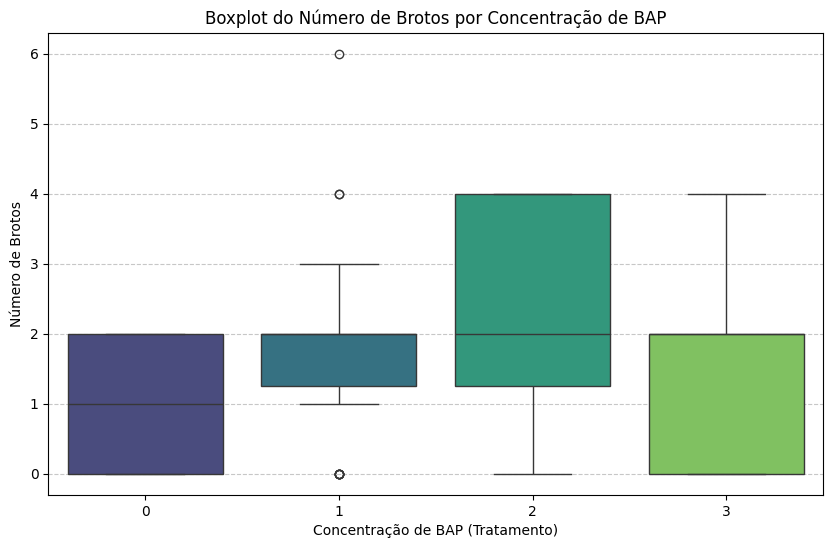

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Tratamento', y='Brotos', data=df, palette='viridis')
plt.title('Boxplot do Número de Brotos por Concentração de BAP')
plt.xlabel('Concentração de BAP (Tratamento)')
plt.ylabel('Número de Brotos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análise dos Boxplots do Número de Brotos por Tratamento

Observando os boxplots gerados para o número de brotos em cada concentração de BAP, podemos inferir o seguinte:

*   **Tratamento 0 (Controle):**
    *   **Mediana:** A linha central está em 1 broto, indicando que metade dos explantes no grupo controle produziu 1 broto ou menos.
    *   **Dispersão:** A caixa é relativamente pequena, mas há uma concentração de dados em torno da mediana. Os bigodes se estendem de 0 a 2 brotos, mostrando que a maioria dos dados está nesse intervalo.
    *   **Valores Atípicos:** Existem alguns pontos acima do bigode superior (por exemplo, em 3 brotos), que são considerados outliers, sugerindo que alguns explantes no controle tiveram uma brotação ligeiramente maior do que o padrão do grupo.

*   **Tratamento 1:**
    *   **Mediana:** A mediana está em 2 brotos, maior que a do controle.
    *   **Dispersão:** A caixa é um pouco maior que a do controle, indicando maior variabilidade nos valores centrais. Os dados variam mais, com o IQR cobrindo uma faixa mais ampla.
    *   **Valores Atípicos:** Há um outlier significativo em 6 brotos, o que é o valor máximo observado para brotos em toda a amostra, indicando um explante com alta produção.

*   **Tratamento 2:**
    *   **Mediana:** A mediana está em 2 brotos, similar ao Tratamento 1 e maior que o controle.
    *   **Dispersão:** Este tratamento parece ter a maior dispersão geral. A caixa é mais longa, e os bigodes cobrem uma gama maior de valores (de 0 a 4 brotos). Isso é consistente com a maior variância e desvio padrão absoluto que calculamos anteriormente.
    *   **Valores Atípicos:** Não há outliers visíveis acima dos bigodes, sugerindo que, embora a dispersão seja alta, os valores se mantêm dentro de um intervalo esperado para o grupo.

*   **Tratamento 3:**
    *   **Mediana:** A mediana está em 1 broto, similar ao controle, mas com uma distribuição diferente.
    *   **Dispersão:** A caixa é um pouco mais larga que a do controle. Os bigodes se estendem de 0 a 4 brotos, mostrando uma dispersão considerável.
    *   **Valores Atípicos:** Há um outlier em 5 brotos, indicando um explante com brotação acima da média para este grupo.

**Em resumo:**

*   **Mediana:** O Tratamento 1 e o Tratamento 2 mostram as medianas mais altas (2 brotos), sugerindo que essas concentrações de BAP tendem a induzir mais brotos na maioria dos explantes em comparação com o controle e o Tratamento 3.
*   **Dispersão:** O **Tratamento 2** é o que apresenta a maior dispersão no número de brotos, com sua caixa e bigodes cobrindo a maior extensão de valores, sem outliers extremos. O **Tratamento 1** e o **Tratamento 3** também mostram dispersão considerável.
*   **Valores Atípicos:** Os **Tratamentos 0, 1 e 3** apresentam valores atípicos (outliers) na parte superior, indicando que alguns poucos explantes nesses grupos tiveram uma produção de brotos excepcionalmente alta, fora do padrão da maioria.

### Boxplots do Número de Folhas por Concentração de BAP

Agora, vamos visualizar a distribuição do número de folhas para cada tratamento de BAP, utilizando boxplots, para complementar a análise de brotos.

/tmp/ipykernel_1721/632203622.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tratamento', y='Folhas', data=df, palette='viridis')


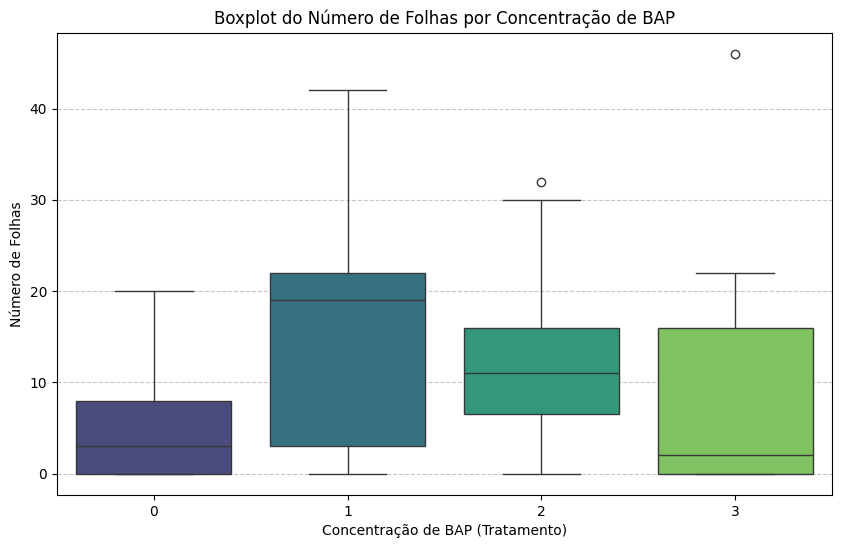

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Tratamento', y='Folhas', data=df, palette='viridis')
plt.title('Boxplot do Número de Folhas por Concentração de BAP')
plt.xlabel('Concentração de BAP (Tratamento)')
plt.ylabel('Número de Folhas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análise de Assimetria e Dispersão dos Boxplots (Brotos e Folhas)

Pergunta 11.

Vamos analisar os boxplots de Brotos (já gerados anteriormente) e os de Folhas (acabamos de gerar) para entender a assimetria e a concentração/dispersão dos dados em cada tratamento.

#### Para o Número de Brotos (Revisão e Foco em Assimetria e Dispersão):

*   **Tratamento 0 (Controle):**
    *   **Assimetria:** A mediana está mais próxima da parte inferior da caixa e o bigode superior é mais longo que o inferior (considerando os outliers), indicando uma **assimetria positiva (à direita)**. Há mais explantes com poucos brotos e alguns com brotação excepcionalmente alta.
    *   **Dispersão/Concentração:** A caixa é relativamente pequena, mas os outliers indicam que, apesar da concentração da maioria, há dispersão nos valores máximos. Os dados centrais são mais concentrados.

*   **Tratamento 1:**
    *   **Assimetria:** A mediana está ligeiramente abaixo do centro da caixa e há um outlier superior expressivo. Isso sugere uma **assimetria positiva (à direita)**.
    *   **Dispersão/Concentração:** A caixa é moderadamente grande, e o outlier indica uma dispersão considerável. Os dados estão menos concentrados que no controle.

*   **Tratamento 2:**
    *   **Assimetria:** A mediana está próxima do centro da caixa, e os bigodes têm comprimentos razoavelmente simétricos. Isso sugere uma distribuição mais **simétrica** ou levemente assimétrica.
    *   **Dispersão/Concentração:** Este tratamento exibe a maior caixa e os bigodes mais longos (sem outliers extremos), indicando a **maior dispersão** dos dados de brotos entre os tratamentos. Os dados estão menos concentrados.

*   **Tratamento 3:**
    *   **Assimetria:** A mediana está próxima da parte inferior da caixa, e há um outlier superior. Isso indica uma **assimetria positiva (à direita)**.
    *   **Dispersão/Concentração:** A caixa é moderada, com bigodes relativamente longos e um outlier, sugerindo uma dispersão considerável, mas com uma concentração da maioria dos dados em valores mais baixos.

#### Para o Número de Folhas:

*   **Tratamento 0 (Controle):**
    *   **Assimetria:** A mediana está muito próxima da parte inferior da caixa, e o bigode superior é muito longo, com vários outliers. Isso mostra uma forte **assimetria positiva (à direita)**, com a maioria dos explantes produzindo poucas folhas e alguns poucos com produção muito alta.
    *   **Dispersão/Concentração:** A caixa é bem pequena, indicando alta concentração da maioria dos dados em valores baixos, mas os múltiplos e distantes outliers no topo demonstram uma **dispersão extrema** para os valores mais altos.

*   **Tratamento 1:**
    *   **Assimetria:** A mediana está ligeiramente abaixo do centro da caixa, e os bigodes são de comprimentos razoáveis, mas com outliers superiores, indicando uma **assimetria positiva (à direita)**.
    *   **Dispersão/Concentração:** A caixa é grande, e há outliers, indicando uma **alta dispersão** nos dados de folhas. Os dados não estão muito concentrados.

*   **Tratamento 2:**
    *   **Assimetria:** A mediana está ligeiramente abaixo do centro da caixa, e os bigodes são de comprimentos razoáveis, sem outliers extremos. Isso sugere uma distribuição mais **simétrica** ou levemente assimétrica.
    *   **Dispersão/Concentração:** A caixa é de tamanho moderado a grande, indicando uma dispersão razoável. Os dados estão menos concentrados que no Tratamento 0.

*   **Tratamento 3:**
    *   **Assimetria:** A mediana está significativamente abaixo do centro da caixa, e o bigode superior é muito longo, com outliers. Isso indica uma forte **assimetria positiva (à direita)**.
    *   **Dispersão/Concentração:** A caixa é de tamanho moderado, mas os bigodes longos e os outliers mostram uma **alta dispersão**, com a maioria dos dados concentrada em valores mais baixos.

### Resumo da Concentração e Dispersão:

*   **Mais Concentrados (Menor Dispersão):**
    *   Para Brotos: **Tratamento 0** (controle) tem a maior concentração para a maioria dos dados (menor IQR).
    *   Para Folhas: **Tratamento 0** (controle) também mostra a maior concentração para a maioria dos dados (menor IQR), mas com outliers que puxam a média e o desvio padrão.

*   **Mais Dispersos (Maior Variabilidade):**
    *   Para Brotos: O **Tratamento 2** apresenta a maior dispersão geral (maior caixa e bigodes), seguido de perto pelo **Tratamento 1** e **Tratamento 3** (que também têm outliers).
    *   Para Folhas: O **Tratamento 1** e o **Tratamento 3** apresentam a maior dispersão geral (caixas grandes, bigodes longos e muitos outliers), e o **Tratamento 0** tem extrema dispersão nos outliers, apesar da concentração dos 50% centrais.